In [1]:
import numpy as np
import xarray as xr
import pandas as pd
from salishsea_tools import viz_tools, places, visualisations
from matplotlib import pyplot as plt, dates
from datetime import datetime, timedelta
from calendar import month_name
from scipy.io import loadmat
from tqdm.notebook import tqdm
from salishsea_tools import nc_tools
from dask.diagnostics import ProgressBar
import cmocean
from pathlib import Path
import arrow

%matplotlib inline

In [2]:
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 'medium'})

### Load files from monthly averages

In [3]:
# Load monthly averages
mask = xr.open_dataset('/ocean/ksuchy/MOAD/NEMO-forcing/grid/mesh_mask202108.nc')
slc =  {'y': slice(450,500), 'x': slice(250,300)} #coordinates for 201905 are y and x
e3t, tmask = [mask[var].isel(z=slice(None, 27),**slc).values for var in ('e3t_0', 'tmask')]
years, variables = range(2007, 2026), ['votemper']


# Temporary list dict
data = {}


# Permanent aggregate dict
aggregates = {var: {} for var in variables}



slc = {'gridY': slice(450,500), 'gridX': slice(250,300)} #redefine with gridY and gridX for biol dataset because there are new coordinate names for 202111 model run

# Loop through years
for year in years:
    jan = arrow.get(f"{year}-01-01")
    dec = arrow.get(f"{year}-12-01")
    
    for var in variables: 
        data[var] = []
    # Load monthly averages 
    months = arrow.Arrow.range("month", jan, dec)
    for month in months:
        yyyymmdd_first = month.format("YYYYMMDD")
        yyyymmdd_last = month.shift(months=+1).shift(days=-1).format("YYYYMMDD")
        ds_file = f"/results2/SalishSea/month-avg.202111/SalishSeaCast_1m_grid_T_{yyyymmdd_first}_{yyyymmdd_last}.nc"
   
        
        # Load grazing variables
        with xr.open_dataset(ds_file) as ds:
            for var in ['votemper']:
                data[var].append(ds.votemper.isel(depth=0, **slc).values)
                
    # Concatenate months
    for var in variables: aggregates[var][year] = np.concatenate(data[var]).mean(axis=0)
        
        
# Calculate climatological mean and anomalies
for var in variables:
    aggregates[var]['mean'] = np.concatenate([aggregates[var][year][None, ...] for year in years]).mean(axis=0)
    for year in years: aggregates[var][year] = aggregates[var][year] - aggregates[var]['mean']

In [4]:
print(np.shape(aggregates['votemper'][2015][:]))

(50, 50)


In [5]:
# Reset variables for plotting
tmask = tmask[0, 0, ...]
variables = ['votemper']

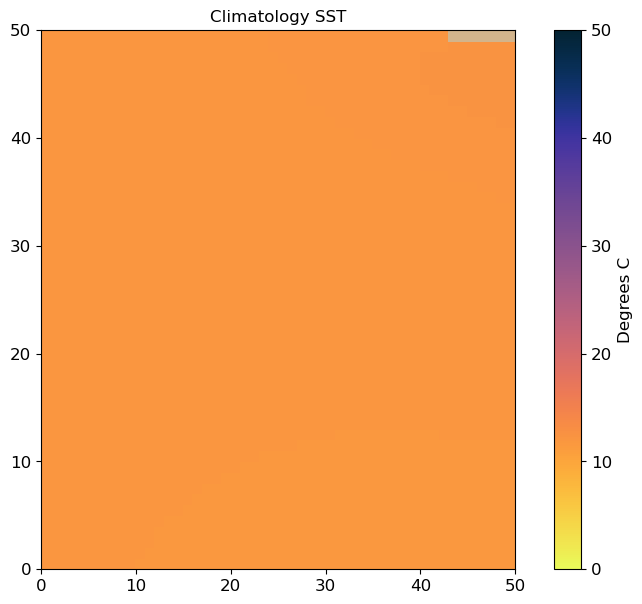

In [6]:
##### with pcolormesh: no smoothing
cmap0=cmocean.cm.balance
cmap0.set_bad('tan')
vmin=0
vmax=50
cmap1=cmocean.cm.thermal_r
cmap1.set_bad('tan')
il=0

fig,ax=plt.subplots(1,1,figsize=(10,7))
#fig.suptitle('Annual Anomalies Mesozoop Feeding on Diatoms', fontsize=16)
m0=ax.pcolormesh(np.ma.masked_where(tmask==0,((aggregates['votemper']['mean']))),cmap=cmap1,vmin=vmin,vmax=vmax)
viz_tools.set_aspect(ax,coords='grid')
ax.set_title('Climatology SST')
fig.colorbar(m0,ax=ax,label='Degrees C')




### Plot Seasonal Cycles for Individual Years

In [7]:
##### #years, months, data
monthly_array_temp_slice = np.zeros([19,12,50,50])
# Load monthly averages
mask = xr.open_dataset('/ocean/ksuchy/MOAD/NEMO-forcing/grid/mesh_mask202108.nc')
slc =  {'y': slice(450,500), 'x': slice(250,300)}
e3t, tmask = [mask[var].isel(z=slice(None, 27),**slc).values for var in ('e3t_0', 'tmask')]
years, variables = range(2007, 2026), ['votemper']

# Temporary list dict
data = {}
# Permanent aggregate dict
aggregates = {var: {} for var in variables}
monthlydat = {var: {} for var in variables}
slc = {'gridY': slice(450,500), 'gridX': slice(250,300)} #redefine with gridY and gridX for biol dataset because there are new coordinate names for 202111 model run



# Loop through years
for year in years:
    jan = arrow.get(f"{year}-01-01")
    dec = arrow.get(f"{year}-12-01")
    
    for var in variables: 
        data[var] = []
    # Load monthly averages 
    months = arrow.Arrow.range("month", jan, dec)
    for month in months:
        yyyymmdd_first = month.format("YYYYMMDD")
        yyyymmdd_last = month.shift(months=+1).shift(days=-1).format("YYYYMMDD")
        ds_file = f"/results2/SalishSea/month-avg.202111/SalishSeaCast_1m_grid_T_{yyyymmdd_first}_{yyyymmdd_last}.nc"
   
        
        
        # Load grazing variables
        with xr.open_dataset(ds_file) as ds:
            q = ds.votemper.isel(depth=0, **slc).values
            q2 = q[0,:,:]
            monthly_array_temp_slice[year-2007,month.month-1,:,:] = q2 #year2007 is index 0 along 1st dimension
            for var in ['votemper']:
                data[var].append(ds.votemper.isel(depth=0, **slc).values)
    
    # Concatenate months
    for var in variables: aggregates[var][year] = np.concatenate(data[var]).mean(axis=0) #[year] might have to be changed with arrow "year.year"?



In [8]:
monthly_array_temp_slice[monthly_array_temp_slice == 0 ] = np.nan
monthly_array_temp_slicemean = \
np.nanmean(np.nanmean(monthly_array_temp_slice, axis = 2),axis = 2)
print(np.shape(monthly_array_temp_slicemean))



(19, 12)


In [9]:
monthly_array_temp_slicemean

array([[ 5.81792306,  6.43329611,  7.50343144, 10.03923295, 13.55126339,
        17.02115078, 18.96100437, 19.45056794, 15.59825812, 11.42769104,
         8.69103712,  6.6991284 ],
       [ 6.20383488,  6.03715865,  7.57581426,  9.10948587, 12.66329843,
        16.1450644 , 18.18821724, 18.23175172, 15.36893514, 12.03689844,
         9.34342432,  6.52110786],
       [ 5.62303129,  6.21668487,  6.80344331,  9.47264291, 12.57861674,
        17.63601414, 18.35432808, 19.89642528, 16.75412783, 11.90332327,
         9.23518015,  5.93065014],
       [ 6.95464927,  7.42119327,  8.44469443,  9.5086912 , 12.59430215,
        15.92660274, 18.33047179, 19.44124454, 15.69348422, 12.59871575,
         9.41724906,  7.17897137],
       [ 6.05800359,  6.21406145,  7.05395108,  8.86331016, 12.32637049,
        16.49162125, 19.14022046, 19.48905261, 16.2367327 , 12.07995558,
         8.86440018,  6.56482258],
       [ 6.41706354,  6.61031841,  6.99325429,  9.45134956, 12.45617652,
        15.05846034, 1

### Select 4 warmest and 4 coldest years; leave NPGO "neutral" years out

In [10]:
#2008, 2010, 2011, 2012
NPGO_C=(((+monthly_array_temp_slicemean[1,:]+\
        monthly_array_temp_slicemean[3,:]+\
        monthly_array_temp_slicemean[4,:]+monthly_array_temp_slicemean[5,:])/4))

In [11]:
#2017, 2018, 2019, 2020
NPGO_W=(((monthly_array_temp_slicemean[10,:]+\
        monthly_array_temp_slicemean[11,:]+monthly_array_temp_slicemean[12,:]+\
        monthly_array_temp_slicemean[13,:])/4))

In [13]:
#2008, 2010, 2011, 2012
NPGO_C=np.array([[monthly_array_temp_slicemean[1,:]],[monthly_array_temp_slicemean[3,:]],\
        [monthly_array_temp_slicemean[4,:]],[monthly_array_temp_slicemean[5,:]]])

In [14]:
NPGO_C_mean=NPGO_C.mean(axis=0).flatten()

In [15]:
NPGO_C_std=NPGO_C.std(axis=0).flatten()

In [16]:
NPGO_C_mean

array([ 6.40838782,  6.57068294,  7.51692852,  9.2332092 , 12.51003689,
       15.90543718, 18.59467292, 19.10888543, 15.86609033, 12.03610209,
        9.0738465 ,  6.87895031])

In [17]:
NPGO_C_std

array([0.3402528 , 0.53309611, 0.58154964, 0.26249205, 0.12963798,
       0.5288787 , 0.37023064, 0.51270089, 0.35489578, 0.41449573,
       0.31516068, 0.3373004 ])

In [18]:
#2015, 2018, 2019, 2020
NPGO_W=np.array([[monthly_array_temp_slicemean[8,:]],[monthly_array_temp_slicemean[11,:]],\
        [monthly_array_temp_slicemean[12,:]],[monthly_array_temp_slicemean[13,:]]])


In [19]:
NPGO_W_mean=NPGO_W.mean(axis=0).flatten()

In [20]:
NPGO_W_std=NPGO_W.std(axis=0).flatten()

In [21]:
NPGO_W_mean

array([ 6.53690677,  6.32478383,  7.7833066 , 10.28009013, 14.72224464,
       17.11397745, 19.40485569, 19.46681836, 16.07259458, 12.49266227,
        8.94083234,  7.17489131])

In [22]:
NPGO_W_std

array([0.14298184, 0.79772622, 0.63326391, 0.23523366, 0.60521061,
       0.37458596, 0.69257106, 1.23579013, 0.86468584, 0.56719888,
       0.33155791, 0.49924014])

Text(0, 0.5, 'Degrees C')

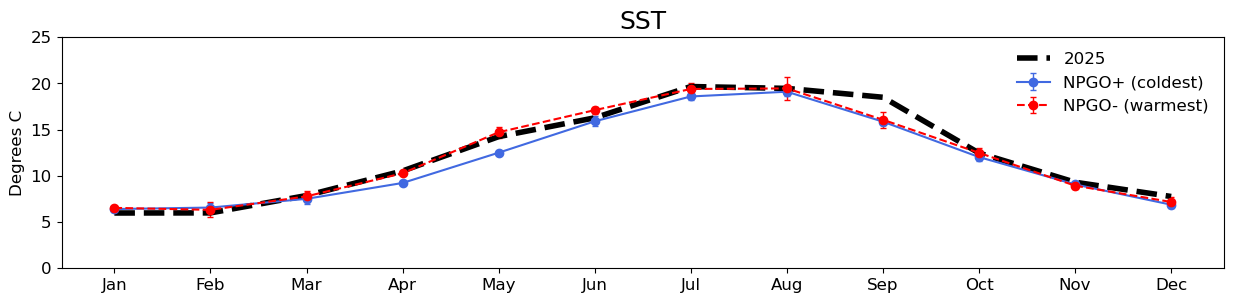

In [23]:
fig, ax = plt.subplots(figsize=(15, 3))
bbox = {'boxstyle': 'round', 'facecolor': 'w', 'alpha': 0.9}
cmap = plt.get_cmap('tab10')
palette = [cmap(0), cmap(0.2), 'k', cmap(0.1), cmap(0.3)]
xticks=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov',"Dec"]

#ax.plot(np.arange(1,13), NPGO_C_mean,label='NPGO+ coldest')
ax.errorbar(xticks,NPGO_C_mean,yerr=NPGO_C_std,fmt='o',linestyle='-',color='royalblue',ecolor = 'royalblue', elinewidth = 1, capsize = 2,label='NPGO+ (coldest)')
#ax.plot(np.arange(1,13), NPGO_W_mean,linestyle='--',label='NPGO- warmest',color='r')
ax.errorbar(xticks,NPGO_W_mean,yerr=NPGO_W_std,fmt='o',linestyle='--',color='r',ecolor = 'r', elinewidth = 1, capsize = 2,label='NPGO- (warmest)')
ax.plot(xticks, monthly_array_temp_slicemean[18,:],color='k',linestyle='--',label='2025',linewidth=4)
ax.set_title('SST',fontsize=18)
ax.legend(frameon=False)
ax.set_ylim(0,25)
ax.set_ylabel('Degrees C',fontsize=12)

In [25]:
temp_clim=(monthly_array_temp_slicemean[0,:]+
 monthly_array_temp_slicemean[1,:]+
 monthly_array_temp_slicemean[2,:]+
 monthly_array_temp_slicemean[3,:]+
 monthly_array_temp_slicemean[4,:]+
 monthly_array_temp_slicemean[5,:]+
 monthly_array_temp_slicemean[6,:]+
 monthly_array_temp_slicemean[7,:]+
 monthly_array_temp_slicemean[8,:]+
 monthly_array_temp_slicemean[9,:]+
 monthly_array_temp_slicemean[10,:]+
 monthly_array_temp_slicemean[11,:]+
 monthly_array_temp_slicemean[12,:]+
 monthly_array_temp_slicemean[13,:]+
 monthly_array_temp_slicemean[14,:]+
 monthly_array_temp_slicemean[15,:]+
 monthly_array_temp_slicemean[16,:]+
monthly_array_temp_slicemean[17,:]+
          monthly_array_temp_slicemean[18,:])/19
 

In [26]:
temp_clim

array([ 6.12203398,  6.31494412,  7.592259  ,  9.92809513, 13.65960564,
       16.75969845, 19.38392901, 19.5276043 , 16.50519839, 12.30670762,
        9.00289474,  6.85600794])

In [27]:
print(
monthly_array_temp_slicemean[0,:].mean()-temp_clim.mean(),
monthly_array_temp_slicemean[1,:].mean()-temp_clim.mean(),
monthly_array_temp_slicemean[2,:].mean()-temp_clim.mean(),
monthly_array_temp_slicemean[3,:].mean()-temp_clim.mean(),
monthly_array_temp_slicemean[4,:].mean()-temp_clim.mean(),
monthly_array_temp_slicemean[5,:].mean()-temp_clim.mean(),
monthly_array_temp_slicemean[6,:].mean()-temp_clim.mean(),
monthly_array_temp_slicemean[7,:].mean()-temp_clim.mean(),
monthly_array_temp_slicemean[8,:].mean()-temp_clim.mean(),
monthly_array_temp_slicemean[9,:].mean()-temp_clim.mean(),
monthly_array_temp_slicemean[10,:].mean()-temp_clim.mean(),
monthly_array_temp_slicemean[11,:].mean()-temp_clim.mean(),
monthly_array_temp_slicemean[12,:].mean()-temp_clim.mean(),
monthly_array_temp_slicemean[13,:].mean()-temp_clim.mean(),
monthly_array_temp_slicemean[14,:].mean()-temp_clim.mean(),
monthly_array_temp_slicemean[15,:].mean()-temp_clim.mean(),
monthly_array_temp_slicemean[16,:].mean()-temp_clim.mean(),
monthly_array_temp_slicemean[17,:].mean()-temp_clim.mean(),
monthly_array_temp_slicemean[18,:].mean()-temp_clim.mean())

-0.23041613282511975 -0.5444989250131567 -0.29620919046989336 -0.03739237721634758 -0.38137301479232555 -0.45531840837345605 -0.0368916840748259 0.3042186777552427 0.269584128174456 0.028895281819551144 -0.16969669018995326 0.34801259050139066 0.10502235048932818 0.06237615611857983 0.17865762362411886 0.07337010350483553 0.1655612708211418 0.2705307613242738 0.34556747882216854


In [28]:
spring_clim=(monthly_array_temp_slicemean[0,(3,4,5)]+\
            monthly_array_temp_slicemean[1,(3,4,5)]+\
            monthly_array_temp_slicemean[2,(3,4,5)]+monthly_array_temp_slicemean[3,(3,4,5)]+\
            monthly_array_temp_slicemean[4,(3,4,5)]+monthly_array_temp_slicemean[5,(3,4,5)]+\
            monthly_array_temp_slicemean[6,(3,4,5)]+monthly_array_temp_slicemean[7,(3,4,5)]+\
            monthly_array_temp_slicemean[8,(3,4,5)]+monthly_array_temp_slicemean[9,(3,4,5)]+\
            monthly_array_temp_slicemean[10,(3,4,5)]+monthly_array_temp_slicemean[11,(3,4,5)]+\
            monthly_array_temp_slicemean[12,(3,4,5)]+monthly_array_temp_slicemean[13,(3,4,5)]+\
                monthly_array_temp_slicemean[14,(3,4,5)]+monthly_array_temp_slicemean[15,(3,4,5)]+\
                monthly_array_temp_slicemean[16,(3,4,5)]+monthly_array_temp_slicemean[17,(3,4,5)]+\
            monthly_array_temp_slicemean[18,(3,4,5)])/19

In [29]:
spring_clim_mean=np.mean(spring_clim[0:3],axis=0)

In [30]:
np.shape(monthly_array_temp_slicemean)

(19, 12)

In [31]:
spring_clim_mean

13.449133071350497

In [32]:
np.mean(np.mean(monthly_array_temp_slicemean[4:7],axis=1))

11.705387156811973

In [33]:
monthly_array_temp_slicemean[0,3:6].mean()

13.537215705710688

In [34]:
## Print spring (March - May)

print(
(monthly_array_temp_slicemean[0,3:6].mean())-spring_clim_mean,
(monthly_array_temp_slicemean[1,3:6].mean())-spring_clim_mean,
(monthly_array_temp_slicemean[2,3:6].mean())-spring_clim_mean,
(monthly_array_temp_slicemean[3,3:6].mean())-spring_clim_mean,
(monthly_array_temp_slicemean[4,3:6].mean())-spring_clim_mean,
(monthly_array_temp_slicemean[5,3:6].mean())-spring_clim_mean,
(monthly_array_temp_slicemean[6,3:6].mean())-spring_clim_mean,
(monthly_array_temp_slicemean[7,3:6].mean())-spring_clim_mean,
(monthly_array_temp_slicemean[8,3:6].mean())-spring_clim_mean,
(monthly_array_temp_slicemean[9,3:6].mean())-spring_clim_mean,
(monthly_array_temp_slicemean[10,3:6].mean())-spring_clim_mean,
(monthly_array_temp_slicemean[11,3:6].mean())-spring_clim_mean,
(monthly_array_temp_slicemean[12,3:6].mean())-spring_clim_mean,
(monthly_array_temp_slicemean[13,3:6].mean())-spring_clim_mean,
(monthly_array_temp_slicemean[14,3:6].mean())-spring_clim_mean,
(monthly_array_temp_slicemean[15,3:6].mean())-spring_clim_mean,
(monthly_array_temp_slicemean[16,3:6].mean())-spring_clim_mean,
(monthly_array_temp_slicemean[17,3:6].mean())-spring_clim_mean,
(monthly_array_temp_slicemean[18,3:6].mean())-spring_clim_mean)


0.08808263436019104 -0.809850172326934 -0.22004180549952146 -0.772601040925716 -0.8886991054962401 -1.1271376007793013 -0.15047574437582512 0.3303583044416083 0.9766025278014236 0.9582753128039467 -0.035462680843830086 0.6169147529485954 0.4650382279883303 0.2999951688896907 0.4669688583361733 -0.5781209388952817 0.4192467963329669 -0.2774291455728779 0.23833565081259245
